In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
%pip install -q -U -r requirements.txt
%pip install uv --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
dbutils.library.restartPython()

In [5]:
import asyncio
import functools
import os
import time
import uuid
from datetime import datetime
from typing import Any, Dict, Generator, List, Literal, Optional
from zoneinfo import ZoneInfo

import mlflow
from databricks.sdk import WorkspaceClient
from databricks_langchain import ChatDatabricks
from databricks_langchain.genie import GenieAgent
from langchain_core.runnables import RunnableLambda
from langgraph.graph import END, StateGraph, add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import create_react_agent
from mlflow.entities import SpanType
from mlflow.pyfunc import ChatAgent
from mlflow.types.agent import (
    ChatAgentChunk,
    ChatAgentMessage,
    ChatAgentResponse,
    ChatContext,
)
from pydantic import BaseModel
from typing_extensions import Annotated, TypedDict
from langgraph.checkpoint.memory import MemorySaver

mlflow.set_tracking_uri("databricks")

######################################
## Load variables from the config file
######################################

# TODO make sure you update the config file
configs = mlflow.models.ModelConfig(development_config="./configs.yaml")
agent_configs = configs.get("agent_configs")

LLM_ENDPOINT_NAME = agent_configs.get("llm").get("endpoint_name")
LLM_TEMPERATURE = agent_configs.get("llm").get("temperature")
GENIE_SPACE_ID = agent_configs.get("genie_agent").get("space_id")
GENIE_DESCRIPTION = agent_configs.get("genie_agent").get("description")
PARALLEL_EXECUTOR_DESCRIPTION = agent_configs.get("parallel_executor_agent").get(
    "description"
)

MAX_ITERATIONS = agent_configs.get("supervisor_agent").get("max_iterations")

SYSTEM_PROMPT = agent_configs.get("supervisor_agent").get("system_prompt")
RESEARCH_PROMPT = agent_configs.get("supervisor_agent").get("research_prompt")
FINAL_ANSWER_PROMPT = agent_configs.get("supervisor_agent").get("final_answer_prompt")
QUALITY_CHECK_PROMPT = agent_configs.get("supervisor_agent").get("quality_check_prompt")
POST_WORKER_ROUTING_PROMPT = agent_configs.get("supervisor_agent").get("post_worker_routing_prompt")

MAX_CONVERSATION_MESSAGES = agent_configs.get("conversation", {}).get("max_messages", 7)


class QueryCache:
    """Simple TTL-based cache to avoid redundant Genie calls for repeated queries."""

    def __init__(self, ttl_seconds: int = 300):
        self._cache: Dict[str, tuple] = {}
        self._ttl = ttl_seconds

    def get(self, query: str) -> Optional[str]:
        key = query.strip().lower()
        if key in self._cache:
            value, ts = self._cache[key]
            if time.time() - ts < self._ttl:
                return value
            del self._cache[key]
        return None

    def set(self, query: str, response: str):
        key = query.strip().lower()
        self._cache[key] = (response, time.time())


genie_cache = QueryCache(ttl_seconds=300)

###################################################
## Create a GenieAgent with access to a Genie Space
###################################################

genie_agent = GenieAgent(
    genie_space_id=GENIE_SPACE_ID,
    genie_agent_name="Genie",
    description=GENIE_DESCRIPTION,
    client=WorkspaceClient(
        host=os.getenv("DB_MODEL_SERVING_HOST_URL"),
        token=os.getenv("DATABRICKS_GENIE_PAT"),
    ),
)

############################################
# Define your LLM endpoint and system prompt
############################################
llm = ChatDatabricks(
    endpoint=LLM_ENDPOINT_NAME,
    temperature=LLM_TEMPERATURE,
)


################################################
# Create calendar functions for temporal context
################################################


def get_temporal_context() -> Dict[str, str]:
    """Return current date, fiscal year, and fiscal quarter.

    Fiscal year runs Sep 1 -> Aug 31, labeled by end year.
    Quarters: Q1=Sep-Nov, Q2=Dec-Feb, Q3=Mar-May, Q4=Jun-Aug
    """
    now = datetime.now(ZoneInfo("America/New_York"))
    today_iso = now.date().isoformat()

    # Fiscal year calculation (Sep-Aug, labeled by end year)
    fy_end_year = now.year + 1 if now.month >= 9 else now.year
    fy = f"FY{fy_end_year}"

    # Fiscal quarter calculation
    if now.month in (9, 10, 11):
        fq = "Q1"
    elif now.month in (12, 1, 2):
        fq = "Q2"
    elif now.month in (3, 4, 5):
        fq = "Q3"
    else:  # Jun, Jul, Aug
        fq = "Q4"

    return {
        "today_iso": today_iso,
        "fy": fy,
        "fq": fq,
    }

In [6]:
#################################################################
# Define the supervisor agent with research planning capabilities
#################################################################

options = ["FINISH", "Genie", "ParallelExecutor"]
FINISH = {"next_node": "FINISH"}


class NextNode(BaseModel):
    next_node: Literal[tuple(options)]


class ResearchPlan(BaseModel):
    queries: List[str]
    rationale: str


class ResearchPlanOutput(BaseModel):
    should_plan_research: bool
    research_plan: Optional[ResearchPlan] = None
    next_node: Literal[tuple(options)]
    refined_query: Optional[str] = None
    confidence: float = 1.0


@mlflow.trace(span_type=SpanType.AGENT, name="supervisor_routing")
def supervisor_agent(state):
    """Supervisor agent node that prepends temporal org context to the system prompt
    and then decides whether to plan research or route normally.

    The injected context includes:
      - Current date (America/New_York)
      - Current fiscal year (FY named by end year, Sep→Aug)
      - Current fiscal quarter (Q1..Q4, with Q1 starting in September)
    """
    try:
        count = state.get("iteration_count", 0) + 1
        if count > MAX_ITERATIONS:
            return FINISH

        temporal_ctx = get_temporal_context()
        temporal_prefix = (
            "Below is information on the current date and fiscal year/quarter information. You may or may not use this in your analysis.\n"
            f"- The current date is: {temporal_ctx['today_iso']}\n"
            f"- The current fiscal year is: {temporal_ctx['fy']}\n"
            f"- The current fiscal quarter is: {temporal_ctx['fq']}\n\n"
        )

        # Use lighter prompt after workers have reported back
        has_worker_response = any(
            (isinstance(m, dict) and m.get("name") in ("Genie", "ParallelExecutor"))
            or (hasattr(m, "name") and getattr(m, "name", None) in ("Genie", "ParallelExecutor"))
            for m in state.get("messages", [])
        )

        if has_worker_response and count > 1 and POST_WORKER_ROUTING_PROMPT:
            system_content = temporal_prefix + SYSTEM_PROMPT + "\n\n" + POST_WORKER_ROUTING_PROMPT
        else:
            system_content = temporal_prefix + SYSTEM_PROMPT + "\n\n" + RESEARCH_PROMPT

        def _build_supervisor_messages(state):
            msgs = [{"role": "system", "content": system_content}]
            for m in state["messages"]:
                if isinstance(m, dict):
                    msgs.append(m)
                else:
                    msg_dict = {"role": getattr(m, "role", "assistant"), "content": getattr(m, "content", str(m))}
                    if hasattr(m, "name") and m.name:
                        msg_dict["name"] = m.name
                    msgs.append(msg_dict)
            # Ensure conversation ends with a user message (Claude rejects assistant-last for structured output)
            if msgs and msgs[-1].get("role") == "assistant":
                msgs.append({"role": "user", "content": "Based on the conversation above, decide the next routing step."})
            return msgs

        supervisor_chain = RunnableLambda(_build_supervisor_messages) | llm.with_structured_output(
            ResearchPlanOutput
        )
        decision = supervisor_chain.invoke(state)
        print(f"[SUPERVISOR] Route={decision.next_node}, confidence={decision.confidence:.2f}, research={decision.should_plan_research}")

        # Prevent infinite loops: allow one re-route to same node, block on second consecutive
        prev_node = state.get("next_node")
        same_node_count = state.get("same_node_count", 0)
        if prev_node == decision.next_node:
            same_node_count += 1
            if same_node_count >= 2:
                return FINISH
        else:
            same_node_count = 0

        result = {
            "iteration_count": count,
            "next_node": decision.next_node,
            "same_node_count": same_node_count,
        }

        # Persist research plan if needed
        if decision.should_plan_research and decision.research_plan:
            result["research_plan"] = {
                "queries": decision.research_plan.queries,
                "rationale": decision.research_plan.rationale,
            }

        if decision.refined_query:
            result["refined_query"] = decision.refined_query

        return result

    except Exception as e:
        # If supervisor fails, finish gracefully with error
        error_message = f"Supervisor routing failed: {str(e)}"
        print(f"[ERROR] {error_message}")
        return FINISH

In [7]:
##############################################
# Research Planner Node for Parallel Execution
##############################################


@mlflow.trace(span_type=SpanType.AGENT, name="research_planner")
async def research_planner_node(state):
    """Execute multiple Genie queries in parallel based on the research plan using asyncio."""
    try:
        research_plan = state.get("research_plan")
        print(f"Research plan: {research_plan}")

        if not research_plan or not research_plan.get("queries"):
            return {
                "messages": [
                    {
                        "role": "assistant",
                        "content": "No research plan found. Unable to execute parallel queries.",
                        "name": "ParallelExecutor",
                    }
                ]
            }

        queries = research_plan["queries"]
        print(f"Queries: {queries}")
        rationale = research_plan.get("rationale", "")
        print(f"Rationale: {rationale}")

        QUERY_TIMEOUT_SECONDS = 120

        @mlflow.trace(span_type=SpanType.AGENT, name="execute_genie_query")
        async def execute_genie_query_async(query: str, max_retries: int = 2) -> Dict[str, Any]:
            """Execute a single Genie query with timeout and retry logic."""
            last_error = None
            for attempt in range(1, max_retries + 1):
                try:
                    query_state = {"messages": [{"role": "user", "content": query}]}
                    result = await asyncio.wait_for(
                        asyncio.to_thread(genie_agent.invoke, query_state),
                        timeout=QUERY_TIMEOUT_SECONDS,
                    )
                    return {
                        "query": query,
                        "success": True,
                        "response": (
                            result["messages"][-1].content
                            if result.get("messages")
                            else "No response"
                        ),
                        "error": None,
                    }
                except asyncio.TimeoutError:
                    last_error = f"Query timed out after {QUERY_TIMEOUT_SECONDS}s (attempt {attempt}/{max_retries})"
                    print(f"[WARN] {last_error}: {query[:80]}...")
                except Exception as e:
                    last_error = f"{str(e)} (attempt {attempt}/{max_retries})"
                    print(f"[WARN] Genie query failed: {last_error}")
                if attempt < max_retries:
                    await asyncio.sleep(2 ** attempt)
            return {
                "query": query,
                "success": False,
                "response": None,
                "error": last_error,
            }

        # Execute queries in parallel using asyncio.gather with error handling
        tasks = [execute_genie_query_async(query) for query in queries]
        results = await asyncio.gather(*tasks, return_exceptions=True)

        # Process results and handle exceptions
        processed_results = []
        for i, result in enumerate(results):
            if isinstance(result, Exception):
                # Convert exception to error result
                error_result = {
                    "query": queries[i],
                    "success": False,
                    "response": None,
                    "error": str(result),
                }
                processed_results.append(error_result)
                print(
                    f"[ERROR] Parallel execution failed for query '{queries[i]}': {str(result)}"
                )
            else:
                processed_results.append(result)

        # Results are already in order due to asyncio.gather preserving order
        ordered_results = processed_results

        # Format the consolidated response
        response_parts = [f"Research Plan: {rationale}\n"]
        response_parts.append("Parallel Research Results:\n")

        for i, result in enumerate(ordered_results, 1):
            response_parts.append(f"\n{i}. Query: {result['query']}")
            if result["success"]:
                response_parts.append(f"   Result: {result['response']}")
            else:
                response_parts.append(f"   Error: {result['error']}")

        # Add synthesis
        response_parts.append(
            f"\n\nSynthesis: The parallel research has gathered comprehensive data from {len(queries)} different angles. This information can now be used to provide a complete answer to the original question."
        )

        consolidated_response = "\n\n".join(response_parts)

        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": consolidated_response,
                    "name": "ParallelExecutor",
                }
            ],
            "research_results": ordered_results,  # Store detailed results for potential further processing
        }

    except Exception as e:
        # If entire parallel research fails, return error message
        error_message = f"Parallel research execution failed: {str(e)}"
        print(f"[ERROR] {error_message}")

        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": f"I encountered an error during parallel research execution: {error_message}. Please try rephrasing your question or ask something simpler.",
                    "name": "ParallelExecutor",
                }
            ]
        }

In [8]:
#######################################
# Define our multiagent graph structure
#######################################


def _extract_user_query(messages):
    """Extract the most recent substantive user query from messages."""
    for msg in reversed(messages):
        if isinstance(msg, dict) and msg.get("role") == "user":
            content = msg.get("content", "")
            if content and content != FINAL_ANSWER_PROMPT:
                return content
        elif hasattr(msg, "role") and msg.role == "user":
            if hasattr(msg, "content") and msg.content and msg.content != FINAL_ANSWER_PROMPT:
                return msg.content
    return None


_GENIE_EMPTY_PATTERNS = [
    "no data found", "no results", "could not find", "couldn't find",
    "unable to retrieve", "no matching", "i don't have",
    "i couldn't", "no records", "data is not available",
    "not available in", "does not exist", "do not have access",
]


def _validate_genie_response(content: str) -> tuple:
    """Check whether a Genie response contains actual data vs an empty/error reply."""
    if not content or not content.strip():
        return False, "Empty response from Genie"
    lower = content.lower()
    for pattern in _GENIE_EMPTY_PATTERNS:
        if pattern in lower:
            return False, f"Genie indicated data unavailability: '{pattern}'"
    return True, ""


def agent_node(state, agent, name):
    """Agent node wrapper that sends a clean, isolated query to the worker agent."""
    query = state.get("refined_query")
    if not query:
        query = _extract_user_query(state.get("messages", []))

    if not query:
        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": "No user query found in the conversation. Please ask a question.",
                    "name": name,
                }
            ]
        }

    @mlflow.trace(span_type=SpanType.AGENT, name=f"{name}_agent_execution")
    def _execute(query: str, agent_name: str):
        print(f"[{agent_name}] Processing query: {query[:100]}...")
        clean_state = {"messages": [{"role": "user", "content": query}]}
        return agent.invoke(clean_state)

    try:
        # Check cache first to avoid redundant Genie calls
        cached_response = genie_cache.get(query)
        if cached_response is not None:
            print(f"[{name}] Cache hit — skipping Genie call")
            response_content = cached_response
        else:
            result = _execute(query, name)

            if not result or "messages" not in result or not result["messages"]:
                raise ValueError(f"Invalid result structure from {name} agent")

            # Collect all message contents from Genie (not just the last one)
            all_contents = []
            for msg in result["messages"]:
                content = msg.content if hasattr(msg, "content") else msg.get("content", "")
                if content and content.strip():
                    all_contents.append(content)
            response_content = "\n\n".join(all_contents) if all_contents else ""

            genie_cache.set(query, response_content)

        is_valid, reason = _validate_genie_response(response_content)
        if not is_valid:
            response_content = (
                f"[Data Gap] {reason}. Original query: {query}\n\n"
                f"Raw response: {response_content}"
            )

        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": response_content,
                    "name": name,
                }
            ],
            "refined_query": None,
        }
    except Exception as e:
        error_message = f"Error in {name} agent: {str(e)}"
        print(f"[ERROR] {error_message}")

        return {
            "messages": [
                {
                    "role": "assistant",
                    "content": f"I encountered an error while processing your request: {error_message}. Please try rephrasing your question or ask something different.",
                    "name": name,
                }
            ],
            "refined_query": None,
        }


class QualityCheckOutput(BaseModel):
    passes_quality_check: bool
    reason: Optional[str] = None


@mlflow.trace(span_type=SpanType.AGENT, name="final_answer")
def final_answer(state):
    """Generate final answer with inline self-reflection quality check."""
    try:
        preprocessor = RunnableLambda(
            lambda state: state["messages"]
            + [{"role": "user", "content": FINAL_ANSWER_PROMPT}]
        )
        final_answer_chain = preprocessor | llm
        answer_msg = final_answer_chain.invoke(state)
        answer_content = answer_msg.content if hasattr(answer_msg, "content") else str(answer_msg)

        user_query = _extract_user_query(state.get("messages", []))
        if user_query and QUALITY_CHECK_PROMPT:
            try:
                check_messages = [
                    {"role": "system", "content": QUALITY_CHECK_PROMPT},
                    {
                        "role": "user",
                        "content": f"Original question: {user_query}\n\nFinal answer: {answer_content}",
                    },
                ]
                quality_result = llm.with_structured_output(QualityCheckOutput).invoke(
                    check_messages
                )

                if not quality_result.passes_quality_check:
                    print(
                        f"[QUALITY] Failed: {quality_result.reason}. Attempting self-correction."
                    )
                    correction_messages = state["messages"] + [
                        {"role": "assistant", "content": answer_content},
                        {
                            "role": "user",
                            "content": (
                                f"Your answer did not pass quality review. Reason: {quality_result.reason}\n\n"
                                "Revise your answer to directly address the question with specific data points. "
                                "If data is insufficient, clearly state what is missing rather than guessing.\n\n"
                                f"{FINAL_ANSWER_PROMPT}"
                            ),
                        },
                    ]
                    corrected_msg = llm.invoke(correction_messages)
                    return {"messages": [corrected_msg]}
            except Exception as qe:
                print(f"[WARN] Quality check skipped due to error: {str(qe)}")

        return {"messages": [answer_msg]}

    except Exception as e:
        error_message = f"Final answer generation failed: {str(e)}"
        print(f"[ERROR] {error_message}")

        try:
            messages = state.get("messages", [])
            if messages:
                last_message = messages[-1]
                fallback_content = f"I apologize, but I encountered an error while generating my final response. Based on the information gathered, here's what I found: {last_message.get('content', 'Unable to retrieve previous response.')} Please try asking your question again."
            else:
                fallback_content = "I apologize, but I encountered an error and couldn't process your request. Please try asking your question again."
        except:
            fallback_content = "I apologize, but I encountered an error and couldn't process your request. Please try asking your question again."

        return {"messages": [{"role": "assistant", "content": fallback_content}]}


class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    next_node: str
    iteration_count: int
    research_plan: Optional[Dict[str, Any]]
    research_results: Optional[List[Dict[str, Any]]]
    refined_query: Optional[str]
    same_node_count: int


genie_node = functools.partial(agent_node, agent=genie_agent, name="Genie")

workflow = StateGraph(AgentState)
workflow.add_node("Genie", genie_node)
workflow.add_node("ParallelExecutor", research_planner_node)
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("final_answer", final_answer)

workflow.set_entry_point("supervisor")
# We want our workers to ALWAYS "report back" to the supervisor when done
for worker in ["Genie", "ParallelExecutor"]:
    workflow.add_edge(worker, "supervisor")

# Let the supervisor decide which next node to go
workflow.add_conditional_edges(
    "supervisor",
    lambda x: x["next_node"],
    {**{k: k for k in ["Genie", "ParallelExecutor"]}, "FINISH": "final_answer"},
)
workflow.add_edge("final_answer", END)
memory = MemorySaver()
multi_agent = workflow.compile(checkpointer=memory)

In [9]:
sample_questions = [
    "Analyze the impact of app version updates on user behavior. Compare metrics between Android versions P.26.0.0 vs P.13.3.0 for the same time period: user engagement, conversion rates, KPI success rates, and feature adoption. Are users on the newer version performing better? Should we force-upgrade legacy users?",
    "What are the lead counts for stage 4 for 6th December?",
]

In [10]:
###################################
# Wrap our multi-agent in ChatAgent
###################################


class LangGraphChatAgent(ChatAgent):
    def __init__(self, agent: CompiledStateGraph):
        self.agent = agent
        # Set up async environment once at initialization
        self._setup_async_environment()

    def _setup_async_environment(self):
        """Configure async environment for Databricks notebooks."""
        try:
            import nest_asyncio

            nest_asyncio.apply()
            self._use_nest_asyncio = True
        except ImportError:
            self._use_nest_asyncio = False

    @mlflow.trace(span_type=SpanType.AGENT, name="user_interaction")
    def predict(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ) -> ChatAgentResponse:
        if self._use_nest_asyncio:
            # Databricks environment - can use asyncio.run directly
            return asyncio.run(self._predict_async(messages, context, custom_inputs))
        else:
            # Fallback for environments without nest_asyncio
            try:
                loop = asyncio.get_running_loop()
                # If we get here, there's already a loop - this shouldn't happen in normal usage
                raise RuntimeError(
                    "Existing event loop detected but nest_asyncio not available. Install nest_asyncio."
                )
            except RuntimeError:
                # No event loop - safe to create one
                return asyncio.run(
                    self._predict_async(messages, context, custom_inputs)
                )

    async def _predict_async(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ) -> ChatAgentResponse:
        thread_id = (
            context.request_id if context and hasattr(context, 'request_id') 
            else str(uuid.uuid4())
        )
        config = {
            "configurable": {
                "thread_id": thread_id,
            }
        }

        if len(messages) > MAX_CONVERSATION_MESSAGES:
            messages = messages[-MAX_CONVERSATION_MESSAGES:]

        request = {
            "messages": [m.model_dump_compat(exclude_none=True) for m in messages]
        }

        final_messages = []
        async for event in self.agent.astream(request, config=config, stream_mode="updates"):
            for node_name, node_data in event.items():
                if node_name == "final_answer":
                    for msg in node_data.get("messages", []):
                        if hasattr(msg, "model_dump_compat"):
                            msg_dict = msg.model_dump_compat(exclude_none=True)
                        elif isinstance(msg, dict):
                            msg_dict = msg
                        else:
                            msg_dict = {
                                "role": getattr(msg, "role", "assistant"),
                                "content": getattr(msg, "content", str(msg)),
                            }
                            if hasattr(msg, "name") and msg.name:
                                msg_dict["name"] = msg.name

                        if "id" not in msg_dict or not msg_dict["id"]:
                            msg_dict["id"] = str(uuid.uuid4())

                        final_messages.append(ChatAgentMessage(**msg_dict))

        return ChatAgentResponse(messages=final_messages)

    @mlflow.trace(span_type=SpanType.AGENT, name="user_interaction_stream")
    def predict_stream(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ) -> Generator[ChatAgentChunk, None, None]:
        # Create an async generator and run it with proper event loop handling
        async def _run_async_stream():
            chunks = []
            async for chunk in self._predict_stream_async(
                messages, context, custom_inputs
            ):
                chunks.append(chunk)
            return chunks

        # Handle event loop properly - same pattern as predict()
        try:
            import nest_asyncio

            nest_asyncio.apply()
            chunks = asyncio.run(_run_async_stream())
        except ImportError:
            try:
                loop = asyncio.get_running_loop()
                import queue
                import threading

                result_queue = queue.Queue()
                exception_queue = queue.Queue()

                def run_in_thread():
                    try:
                        new_loop = asyncio.new_event_loop()
                        asyncio.set_event_loop(new_loop)
                        result = new_loop.run_until_complete(_run_async_stream())
                        result_queue.put(result)
                        new_loop.close()
                    except Exception as e:
                        exception_queue.put(e)

                thread = threading.Thread(target=run_in_thread)
                thread.start()
                thread.join()

                if not exception_queue.empty():
                    raise exception_queue.get()

                chunks = result_queue.get()

            except RuntimeError:
                chunks = asyncio.run(_run_async_stream())

        # Yield chunks synchronously
        for chunk in chunks:
            yield chunk

    async def _predict_stream_async(
        self,
        messages: list[ChatAgentMessage],
        context: Optional[ChatContext] = None,
        custom_inputs: Optional[dict[str, Any]] = None,
    ):
        thread_id = (
            context.request_id if context and hasattr(context, 'request_id') 
            else str(uuid.uuid4())
        )
        config = {
            "configurable": {
                "thread_id": thread_id,
            }
        }

        if len(messages) > MAX_CONVERSATION_MESSAGES:
            messages = messages[-MAX_CONVERSATION_MESSAGES:]

        request = {
            "messages": [m.model_dump_compat(exclude_none=True) for m in messages]
        }

        seen_nodes = set()

        async for event in self.agent.astream(request, config=config, stream_mode="updates"):
            for node_name, node_data in event.items():
                if node_name not in seen_nodes and node_name != "final_answer":
                    seen_nodes.add(node_name)
                    status_msg = {
                        "role": "assistant",
                        "content": f"Processing with {node_name}...",
                        "id": str(uuid.uuid4()),
                    }
                    yield ChatAgentChunk(**{"delta": status_msg})

                if node_name == "final_answer":
                    for msg in node_data.get("messages", []):
                        if hasattr(msg, "model_dump_compat"):
                            msg_dict = msg.model_dump_compat(exclude_none=True)
                        elif isinstance(msg, dict):
                            msg_dict = msg
                        else:
                            msg_dict = {
                                "role": getattr(msg, "role", "assistant"),
                                "content": getattr(msg, "content", str(msg)),
                            }
                            if hasattr(msg, "name") and msg.name:
                                msg_dict["name"] = msg.name

                        if "id" not in msg_dict or not msg_dict["id"]:
                            msg_dict["id"] = str(uuid.uuid4())

                        yield ChatAgentChunk(**{"delta": msg_dict})


# Create the agent object
# mlflow.langchain.autolog() # Disabled due to verbosity issue
AGENT = LangGraphChatAgent(multi_agent)
mlflow.models.set_model(AGENT)


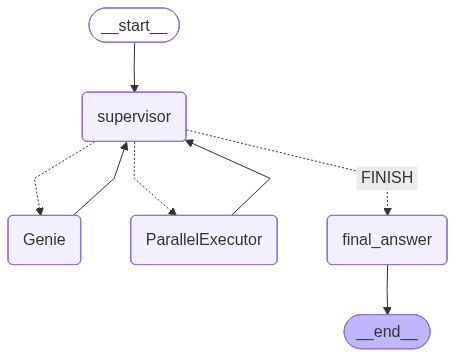

In [11]:
from IPython.display import Image, display

display(Image(AGENT.agent.get_graph().draw_mermaid_png()))

In [12]:
sample_questions = [
    "Analyze the impact of app version updates on user behavior. Compare metrics between Android versions P.26.0.0 vs P.13.3.0 for the same time period: user engagement, conversion rates, KPI success rates, and feature adoption. Are users on the newer version performing better? Should we force-upgrade legacy users?",
    "What are the lead counts for stage 4 for 6th December?",
    "Analyze all KPI failures in the last 7 days. Cluster failures by: time of day, product type, journey stage, platform, and user segments. Are there common patterns? Is a specific product-platform-stage combination causing most failures? What's the correlation between event patterns and KPI failures?",
    "Compare performance metrics between November 2025 and December 2025 across all products: total traffic volume, conversion rates, average journey time, drop-off rates by stage, KPI success rates, and platform mix changes. What are the significant trends? Which products are growing vs declining?"
]

input_example = {
    "messages": [
        {
            "role": "user",
            "content": sample_questions[2],
        }
    ]
}

In [18]:
print(sample_questions[2])

Analyze all KPI failures in the last 7 days. Cluster failures by: time of day, product type, journey stage, platform, and user segments. Are there common patterns? Is a specific product-platform-stage combination causing most failures? What's the correlation between event patterns and KPI failures?


In [13]:
# invoke the agent
response = AGENT.predict(input_example)

2026/03/02 11:56:48 WARNING mlflow.tracing.export.mlflow_v3: Failed to send trace to MLflow backend: INVALID_PARAMETER_VALUE: `trace_info.mlflow_experiment.experiment_id` is missing.


[SUPERVISOR] Route=ParallelExecutor, confidence=0.75, research=True
Research plan: {'queries': ['What are the KPI failure counts broken down by hour of day and product type (PL, BL, HL, Gold Loan, RPL, IPL, SBL) from February 23, 2026 to March 2, 2026?', 'What are the KPI failure counts broken down by journey stage (stage 0 through stage 4) and platform (Android, iOS, Web) from February 23, 2026 to March 2, 2026?', 'What are the top product-platform-stage combinations with the highest KPI failure counts from February 23, 2026 to March 2, 2026?', 'What are the daily event counts and KPI failure counts by product and journey stage from February 23, 2026 to March 2, 2026, to identify correlations between event patterns and KPI failures?'], 'rationale': 'This is a complex multi-dimensional analysis of KPI failures over the last 7 days (Feb 23 - Mar 2, 2026). It requires examining failures across multiple dimensions: time of day, product type, journey stage, platform, and user segments. We 

In [14]:
from IPython.display import Markdown, display

display(Markdown(f"### FINAL RESPONSE:\n\n{response.messages[-1].content}"))

### FINAL RESPONSE:



# KPI Failure Analysis — Last 7 Days

## Analysis Summary

This analysis examines KPI failures across 5 clustering dimensions: time of day, product type, journey stage, platform, and user segments. The data reveals clear concentration patterns that point to specific systemic issues.

---

## 1. Clustering by Time of Day

| Time Window | Hourly Failure Range | Intensity |
|---|---|---|
| **Peak: 11 AM – 1 PM** | 101,405 – 108,646 | 🔴 Critical |
| **High: 3 PM – 8 PM** | 85,214 – 96,918 | 🟠 High |
| **Ramp-up: 8 AM – 10 AM** | 53,127 – 85,170 | 🟡 Moderate |
| **Wind-down: 9 PM – 11 PM** | 32,094 – 75,131 | 🟡 Moderate |
| **Low: 1 AM – 6 AM** | 1,993 – 9,411 | 🟢 Low |

**Pattern:** Failures follow a classic bell curve aligned with user traffic. The **12 PM hour is the single worst hour** at 108,646 failures, suggesting failures are load-correlated rather than caused by scheduled jobs or maintenance windows.

---

## 2. Clustering by Product Type

| Rank | Product | Stage 1 (PDP View) Failures | Total Estimated Failures | Share |
|---|---|---|---|---|
| 1 | **RTL (Retail Loan)** | ~189.3M | ~230M+ | **~33%** |
| 2 | **SALPL (Salaried PL)** | ~134.5M | ~165M+ | **~24%** |
| 3 | **PLCS (PL Cross-Sell)** | ~99.1M | ~115M+ | **~16%** |
| 4 | **ONBOARDING** | ~83.2M | ~95M+ | **~13%** |
| 5 | **PL (Personal Loan)** | ~56.9M | ~65M+ | **~9%** |
| 6 | **PLPPL / PPL** | ~30M+ | ~35M+ | **~5%** |

> **Key Insight:** RTL and SALPL together account for **~57% of all KPI failures**. These two products are the dominant failure contributors.

---

## 3. Clustering by Journey Stage

| Stage | Stage Name | Total Failures (7-day) | % of Total |
|---|---|---|---|
| **Stage 1** | PDP Page View | **~450M+** | **~75–80%** |
| **Stage 3** | Personal Details Page Viewed | ~6.5M | ~5% |
| **Stage 2** | PDP → Apply Now / GACB / Resume | ~5.9M | ~5% |
| **Stage 4** | Personal Details Submit / GACB | ~4.9M | ~4% |
| Onboarding Stage 19 | OTP Submit (Signup) | ~83.2M | ~10% |

> 🚨 **Critical Finding:** **Stage 1 (PDP Page View) is responsible for 75–80% of all KPI failures.** This is the single largest failure concentration point across the entire funnel. The massive drop-off at the very first touchpoint suggests users are landing on product pages but not progressing — indicating potential issues with page load performance, content relevance, or CTA visibility.

---

## 4. Clustering by Platform

| Platform | Stage 1 Failures (Top 3 Products) | Relative Split |
|---|---|---|
| **iOS** | RTL: 104.5M, SALPL: 69.4M, PLCS: 56.9M | **~55%** |
| **Android** | RTL: 84.8M, SALPL: 65.1M, PLCS: 42.4M | **~45%** |

For deeper stages (Stages 3–4):

| Platform | Stage 3 Failures | Stage 4 Failures |
|---|---|---|
| **iOS** | 3,611,088 | 2,894,870 |
| **Android** | 2,881,926 | 2,500,115 |

> **Pattern:** **iOS consistently shows 15–25% higher failure rates than Android** across all stages and products. This is disproportionate and suggests a platform-specific issue — potentially related to iOS app rendering, WebView behavior, or iOS-specific API timeouts.

---

## 5. The Dominant Product-Platform-Stage Combination

| Rank | Combination | 7-Day Failures | % of Grand Total |
|---|---|---|---|
| 🥇 | **RTL × iOS × PDP Page View** | **104,542,500** | **~18%** |
| 🥈 | **RTL × Android × PDP Page View** | **84,817,500** | **~15%** |
| 🥉 | **SALPL × iOS × PDP Page View** | **69,366,250** | **~12%** |
| 4 | **SALPL × Android × PDP Page View** | **65,092,500** | **~11%** |
| 5 | **PLCS × iOS × PDP Page View** | **56,873,750** | **~10%** |
| 6 | **PLCS × Android × PDP Page View** | **42,408,750** | **~7%** |
| 7 | **Onboarding × iOS × OTP Submit** | **41,709,907** | **~7%** |
| 8 | **Onboarding × Android × OTP Submit** | **41,454,018** | **~7%** |

> 🎯 **The top 2 combinations alone (RTL on iOS and Android at PDP Page View) account for ~33% of ALL failures.** The top 6 PDP-related combinations account for **~73%** of total failures.

---

## 6. Event-to-Failure Correlation Analysis

Examining the relationship between event volumes and failure counts:

| Product | Stage | Avg Daily Events | Avg Daily Failures | Failure Rate |
|---|---|---|---|---|
| **RTL** | Stage 1 | ~58M | ~24M | **~41%** |
| **SALPL** | Stage 1 | ~822M | ~16M | **~2%** |
| **PLCS** | Stage 1 | ~98M | ~12M | **~12%** |
| **PL** | Stage 1 | ~3.5B | ~7M | **~0.2%** |
| **Onboarding** | Stage 19 | ~107M | ~9.4M | **~9%** |
| **RTL** | Stage 3 | ~47M | ~2.7M | **~6%** |
| **RTL** | Stage 4 | ~61M | ~1.8M | **~3%** |

> **Key Correlation:** RTL has the **highest failure rate at 41%** at Stage 1 despite not having the highest event volume. This means RTL's PDP page has a fundamental conversion/progression problem — nearly half of all PDP views fail to advance. In contrast, PL has massive volume (3.5B events) but only a 0.2% failure rate, indicating a well-optimized funnel.

---

## Summary of Common Patterns

| Pattern | Evidence |
|---|---|
| **Failures are load-correlated** | Peak at 11 AM–1 PM, following traffic curves |
| **Stage 1 is the bottleneck** | 75–80% of all failures occur at PDP Page View |
| **RTL is the worst offender** | 41% failure rate at Stage 1, highest absolute failures |
| **iOS underperforms Android** | 15–25% higher failure rates consistently |
| **Top-of-funnel dominates** | Deeper stages (3, 4) have dramatically fewer failures |
| **Onboarding OTP is a secondary hotspot** | ~83M failures at OTP Submit stage |

---

## Recommendations

1. **🔴 Immediate — Investigate RTL PDP Page (iOS priority):** The RTL × iOS × PDP Page View combination alone causes ~18% of all failures. Audit page load times, API response times, and content rendering on iOS for RTL product pages.

2. **🔴 Immediate — iOS Platform Audit:** The consistent iOS overrepresentation suggests a systemic platform issue. Check for iOS-specific WebView crashes, memory issues, or SDK incompatibilities.

3. **🟠 High Priority — PDP Page Optimization Across Products:** Since Stage 1 dominates failures across RTL, SALPL, and PLCS, implement PDP page performance monitoring, lazy loading, and CTA A/B testing.

4. **🟠 High Priority — Onboarding OTP Flow:** The ~83M OTP Submit failures suggest SMS delivery issues, timeout problems, or UX friction. Investigate OTP delivery success rates and retry patterns.

5. **🟡 Medium Priority — Load-Based Scaling:** The 11 AM–1 PM peak suggests infrastructure may need auto-scaling adjustments during business hours to handle peak load gracefully.

6. **🟡 Medium Priority — Funnel Drop-off Analysis:** Conduct a deep-dive into *why* users fail at PDP — is it bounce (page load), lack of interest (content), or technical failure (API errors)?

In [15]:
# from mlflow.types.agent import ChatContext

# # Use the same thread_id for related conversations
# thread_id = "user-session-abc123"
# context = ChatContext(request_id=thread_id)

# # First question
# response1 = AGENT.predict(input_example, context=context)

# # Follow-up question (will have memory of first question)
# followup_example = {
#     "messages": [
#         {"role": "user", "content": "Can you elaborate on that last point?"}
#     ]
# }
# response2 = AGENT.predict(followup_example, context=context)

In [16]:
# from IPython.display import Markdown, display

# display(Markdown(f"### FINAL RESPONSE:\n\n{response.messages[-1].content}"))